In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(np.__version__)
print(np.__file__)
print(hasattr(np, "bool"))

data = pd.read_excel(
    "SCI_2025_reshaped_rows.xlsx",
    sheet_name="Data"
)

# Remove units row
data = data.iloc[1:].reset_index(drop=True)

# Convert all columns except Model and Scenario
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values
#data = data.dropna()

print(data.shape)
print(data.dtypes)

2.0.2
/usr/local/lib/python3.12/dist-packages/numpy/__init__.py
True
(1573, 23)
Model                                           object
Scenario                                        object
Emissions|CO2                                  float64
Final Energy                                   float64
Primary Energy                                 float64
Primary Energy|Coal                            float64
Primary Energy|Oil                             float64
Primary Energy|Gas                             float64
Primary Energy|Biomass                         float64
Primary Energy|Nuclear                         float64
Primary Energy|Solar                           float64
Primary Energy|Wind                            float64
Population                                     float64
Food Availability [per capita]                 float64
Agricultural Demand|Crops                      float64
Price|Carbon                                   float64
Capacity|Electricity|Fossil             

In [32]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,...,Food Availability [per capita],Agricultural Demand|Crops,Price|Carbon,Capacity|Electricity|Fossil,Capacity|Electricity|Biomass,Capacity|Electricity|Non-Biomass Renewables,Food Availability [per capita].1,Agricultural Demand|Crops.1,Agricultural Demand|Livestock,Land Cover|Forest
0,AIM/CGE 2.0,SSP1-19,-4474.874100,311.634100,390.247600,4.978500,20.372700,21.605000,86.760600,20.502400,...,3271.7909,4439.7738,2398.749760,492.153200,973.388900,24974.216700,3271.7909,4439.7738,248.0497,5465.042000
1,AIM/CGE 2.0,SSP1-26,17.737700,326.197800,447.017100,29.398500,66.692700,68.069400,77.928700,24.310200,...,3339.8633,4523.5270,423.880820,1716.053800,918.052000,18858.271600,3339.8633,4523.5270,249.8301,4862.783900
2,AIM/CGE 2.0,SSP1-34,9037.781800,348.457500,493.885900,52.403400,98.216800,80.235700,87.855000,23.463100,...,3358.8652,4575.0774,112.680370,2198.864000,1309.429400,15602.858900,3358.8652,4575.0774,250.8319,4402.723200
3,AIM/CGE 2.0,SSP1-45,18738.134600,361.338100,508.013900,58.264100,116.733800,100.113200,76.329300,22.505900,...,3369.8110,4582.8676,42.858200,2920.712600,1115.203700,13714.074200,3369.8110,4582.8676,251.0596,4199.951900
4,AIM/CGE 2.0,SSP1-Baseline,29879.805400,387.116000,576.536600,115.873600,134.964600,123.887100,71.756500,10.535700,...,3378.7550,4593.6824,NaN,4539.632500,1038.480100,12250.503000,3378.7550,4593.6824,251.2209,3935.391500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1568,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-8298.142767,481.152565,801.779905,42.040770,52.074329,69.618349,219.582205,25.240025,...,NaN,NaN,2301.616255,913.163188,1690.623180,38710.515716,NaN,NaN,NaN,4689.517715
1569,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,-1964.924847,521.502532,860.832783,43.787822,92.813528,101.197321,222.641439,25.166012,...,NaN,NaN,1189.180974,1224.005639,1509.450800,36522.817178,NaN,NaN,NaN,4668.206333
1570,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-14222.971415,445.931529,758.458933,41.857787,26.388388,38.958678,227.162166,24.359260,...,NaN,NaN,5620.664725,617.490159,2301.258906,40023.243319,NaN,NaN,NaN,4697.092031
1571,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,79704.641306,695.758625,1266.199768,261.053762,369.605242,311.009919,58.839570,23.595843,...,NaN,NaN,0.946701,6850.003974,100.337914,20822.715195,NaN,NaN,NaN,3902.954037


In [33]:
outcome_interest = 2
factors = list(range(3,11))
#factors = [6, 7, 8, 9]

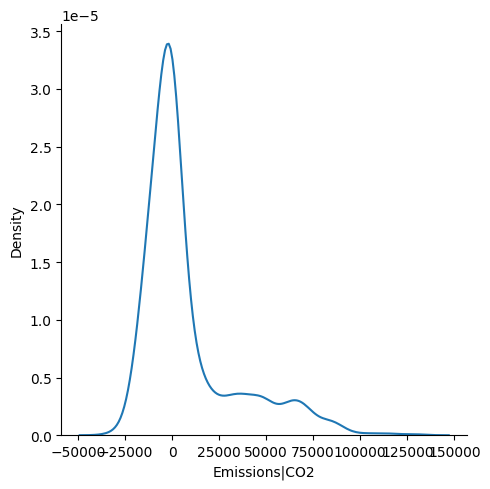

In [34]:

import seaborn as sns
sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [35]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values<threshold_interest<less than X cost per capita

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 783 cases of interest, out of 1573 scenarios


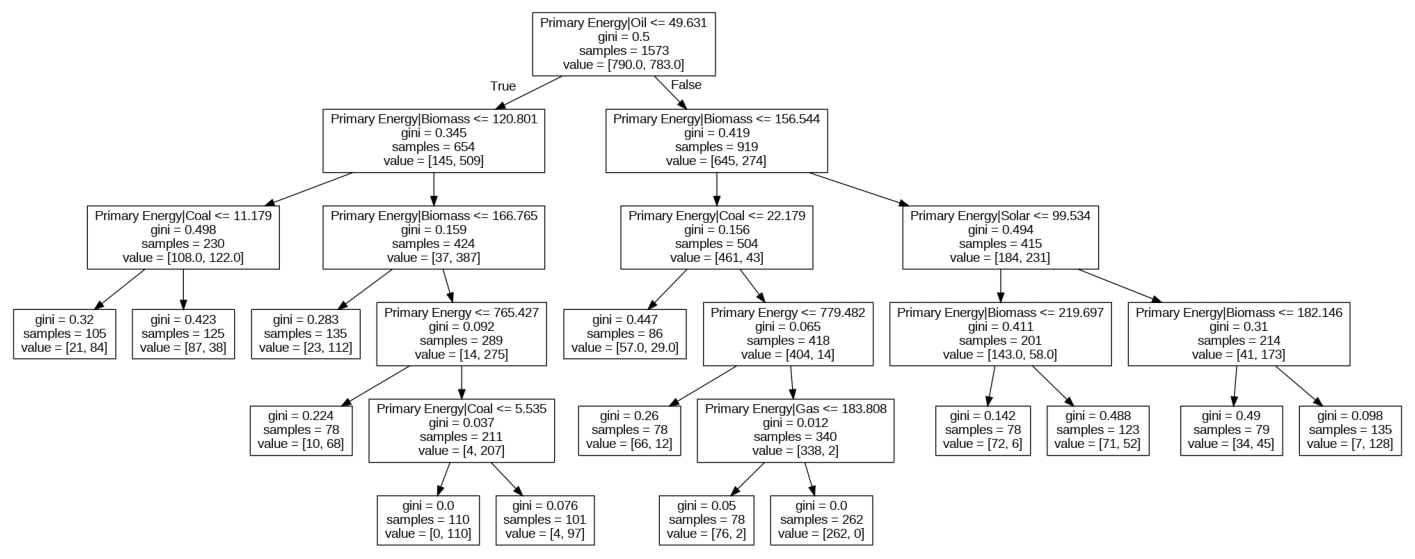

In [36]:
from ema_workbench.analysis import cart

cart_alg = cart.CART(x, y)
cart_alg.build_tree()

fig = cart_alg.show_tree()
fig.set_size_inches((18, 12))
plt.show()

In [37]:
#PRIM analysis
from ema_workbench.analysis import prim
from ema_workbench.util import ema_logging

#ema_logging.log_to_stderr(ema_logging.INFO);

In [38]:
prim_alg = prim.Prim(x, y)
box1 = prim_alg.find_box()

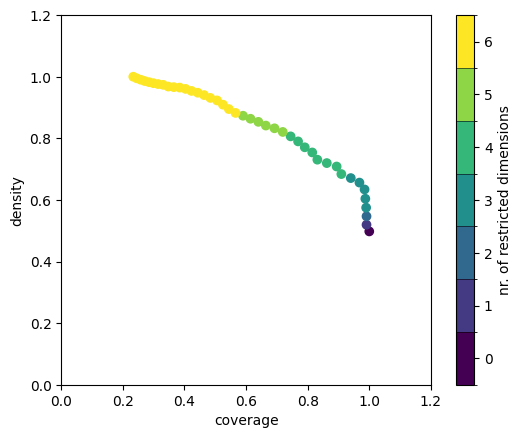

In [39]:
#Visualize first box tradeoff
box1.show_tradeoff()
plt.show()

In [40]:
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [52]:
box1.inspect(style='data')

[(coverage      0.233716
  density       1.000000
  id           41.000000
  k           183.000000
  mass          0.116338
  mean          1.000000
  n           183.000000
  res_dim       6.000000
  Name: 41, dtype: float64,
                              box 41                                         
                                 min          max      qp value      qp value
  Primary Energy          739.548190  1169.234000  4.841775e-03  3.940412e-01
  Primary Energy|Coal       0.008800   117.101304           NaN  3.787706e-01
  Primary Energy|Oil        0.000000    79.570992           NaN  6.588580e-17
  Primary Energy|Gas       28.308597   264.606673  1.000000e+00  1.732899e-03
  Primary Energy|Biomass  180.923650   530.417362  1.790697e-19           NaN
  Primary Energy|Nuclear   16.852201   251.698000  1.574731e-01           NaN)]

In [45]:
box2 = prim_alg.find_box()
box2.inspect()

coverage      0.298851
density       0.661017
id           25.000000
k           234.000000
mass          0.225048
mean          0.661017
n           354.000000
res_dim       4.000000
Name: 25, dtype: float64

                            box 25                                
                               min         max  qp value  qp value
Primary Energy|Coal       0.008800  116.289402       NaN  0.238546
Primary Energy|Oil        0.000000  101.164821       NaN  0.000158
Primary Energy|Gas        0.004300  318.749644       NaN  0.465984
Primary Energy|Biomass  110.374313  340.739219  0.000001  0.542897



[None]

In [53]:
selected = box1.yi

data_selected = data.loc[selected]

print(data_selected['Scenario'].value_counts())

Scenario
ENGAGE-NPi2020-400f            5
ENGAGE-NPi2020-500f            4
ENGAGE-NPi2020-600f            4
ENGAGE-INDCi2030-800f          4
ENGAGE-NPi2020-900f            3
                              ..
PEP-2°C-Full-CDR-NDC           1
PEP-2°C-Full-CDR-NetZero       1
ENGAGE-INDCi2030-1200f-NDCp    1
ENGAGE-INDCi2030-1400f-NDCp    1
ENGAGE-INDCi2030-900f-NDCp     1
Name: count, Length: 128, dtype: int64


In [51]:
box3 = prim_alg.find_box()
box3.inspect()

coverage      0.155811
density       0.521368
id           26.000000
k           122.000000
mass          0.148760
mean          0.521368
n           234.000000
res_dim       6.000000
Name: 26, dtype: float64

                            box 26                                
                               min         max  qp value  qp value
Final Energy            195.651200  902.459900       NaN  0.499335
Primary Energy|Coal       0.008800  129.121761       NaN  0.223932
Primary Energy|Oil        0.000000  149.854924       NaN  0.142168
Primary Energy|Gas        0.004300  152.721398       NaN  0.000042
Primary Energy|Biomass   24.714049  276.951825  0.499335  0.315749
Primary Energy|Nuclear    0.236850  251.698000  0.408228       NaN



[None]